In [1]:
from sklearn import datasets #EZ way to load data
from sklearn.tree import DecisionTreeClassifier #decision tree, basis of RF
from sklearn.ensemble import RandomForestClassifier #RF, uses Decision tree idea
from sklearn.model_selection import train_test_split #Lazy splitting/testing
from sklearn import tree #base tree Plotters
from sklearn.tree import plot_tree #RF plotters
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Load the Iris dataset
iris = datasets.load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


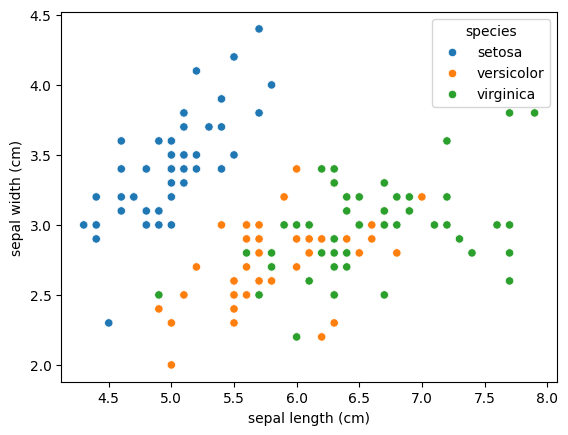

In [3]:
sns.scatterplot(data=df, x=iris.feature_names[0], y=iris.feature_names[1], hue='species');

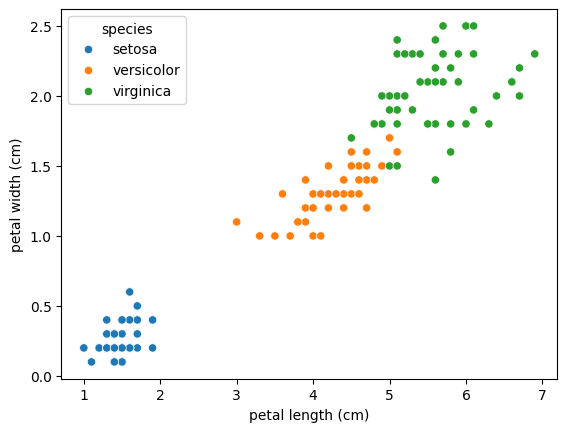

In [4]:
sns.scatterplot(data=df, x=iris.feature_names[2], y=iris.feature_names[3], hue='species');

In [5]:
X = df.iloc[:,1:4]  # We use all 4 features.
y = df['species']

# Split quick for train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train decision tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict on the testing set
predictions = clf.predict(X_test)

# See overall accuracy
accuracy = clf.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 1.0


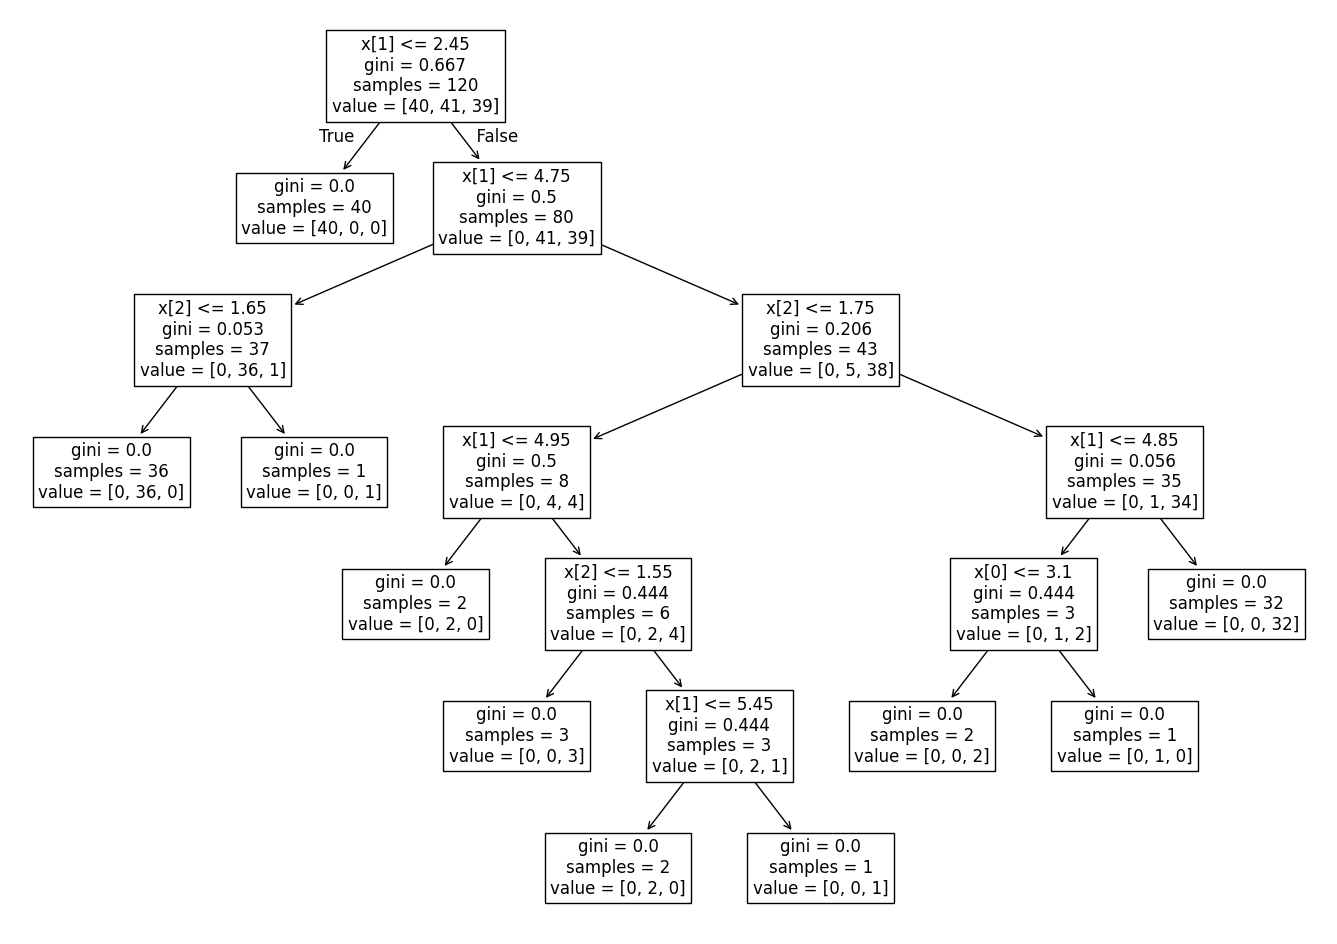

In [6]:
# Visualize a single decision tree
plt.figure(figsize=(17,12))
tree.plot_tree(clf, fontsize = 12);

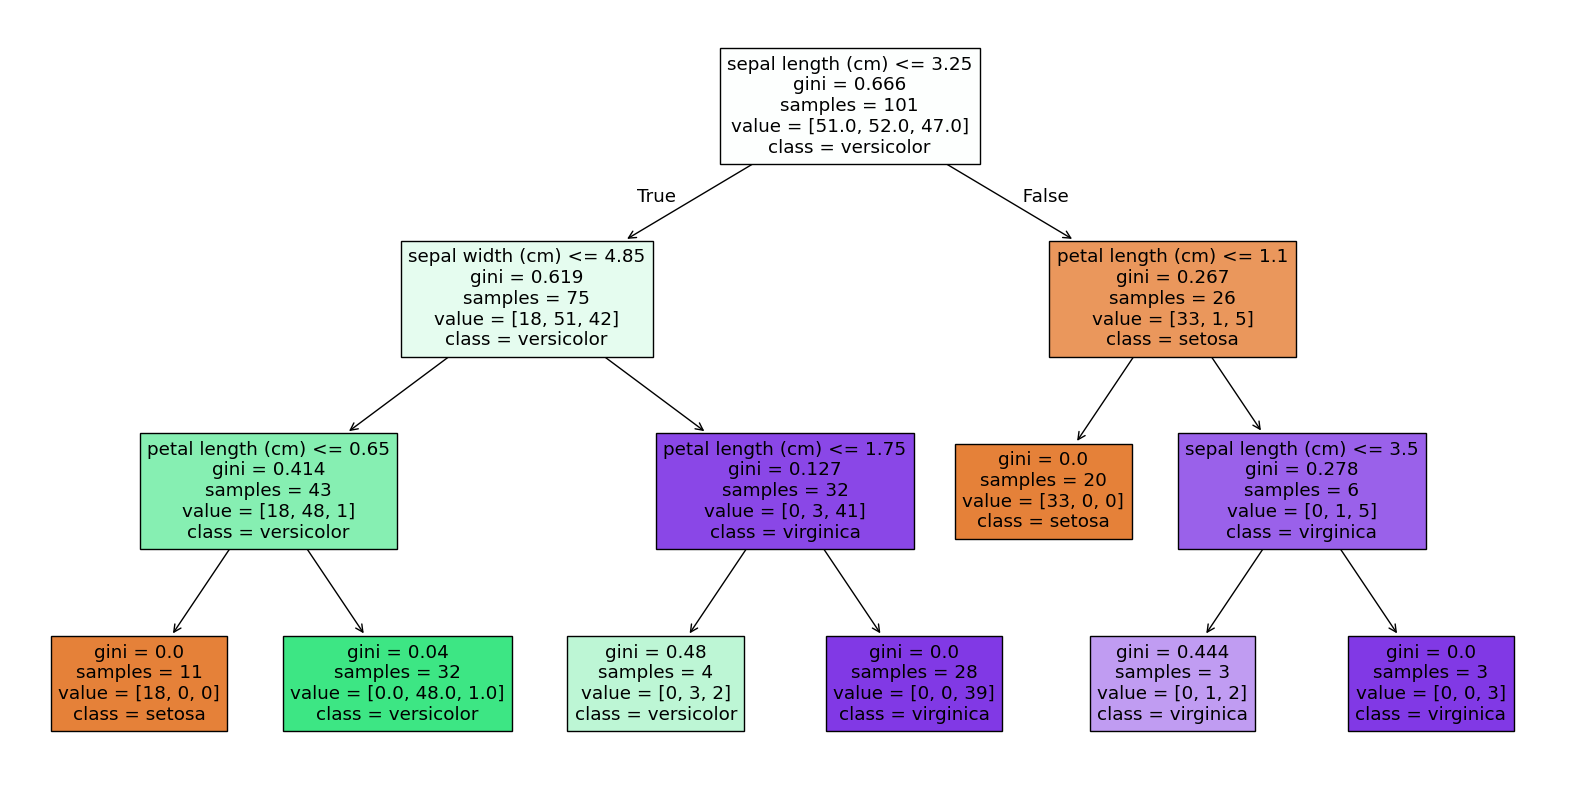

In [7]:
rf = RandomForestClassifier(n_estimators=1, max_depth=3, random_state=42)
rf.fit(X, y)

# Plot one tree from the forest
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0], feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

In [9]:
dfTitan = pd.read_csv('titanic3.csv')
dfTitan

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,NaN,C,NaN,NaN,NaN
1308,3.0,0.0,"Zimmerman, Mr. Leo",male,29.0000,0.0,0.0,315082,7.8750,NaN,S,NaN,NaN,NaN


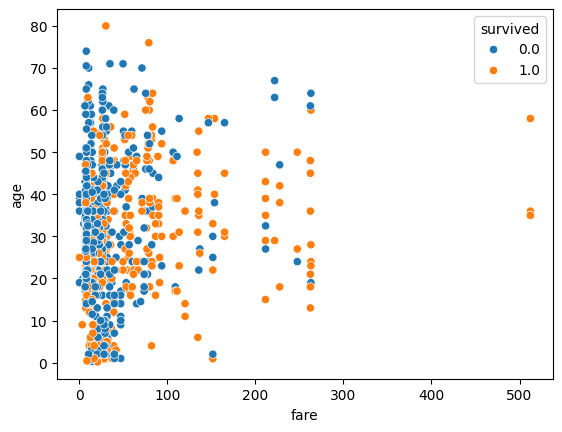

In [10]:
sns.scatterplot(data=dfTitan, x=dfTitan['fare'], y=dfTitan['age'], hue='survived');

In [13]:
dfTitan = dfTitan[['fare','age','pclass','sibsp','survived']].dropna()
X = dfTitan[['fare','age','pclass','sibsp']]  # We use all 4 features.
y = dfTitan['survived']

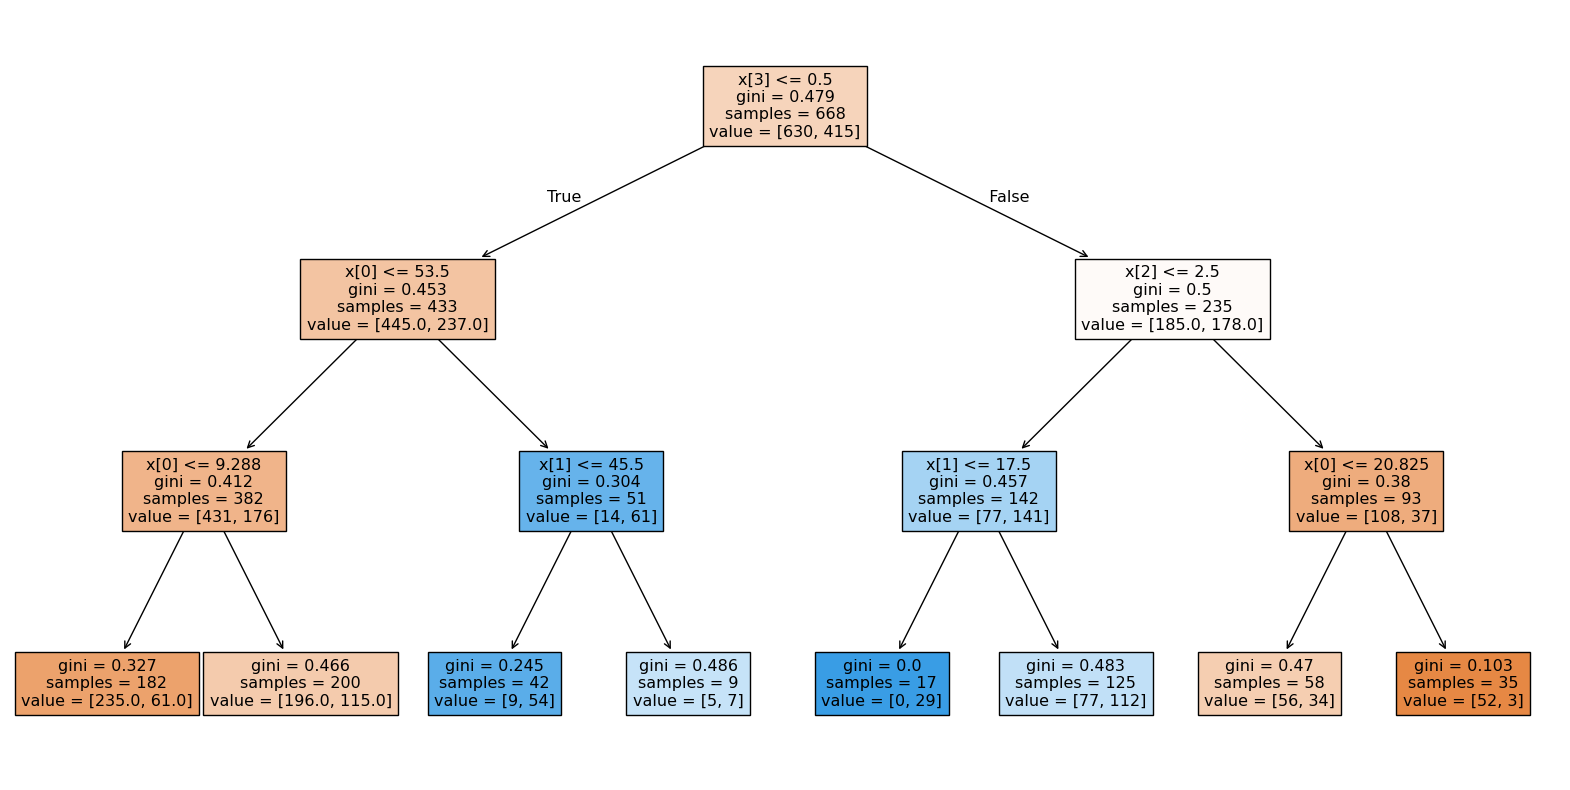

In [15]:
rf = RandomForestClassifier(n_estimators=1, max_depth=3, random_state=42)
rf.fit(X, y)

# Plot one tree from the forest
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0], filled=True)
plt.show()